# Preset: `env36`

In [1]:
import os
import matplotlib.pyplot as plt

os.chdir('../src/mazebots')

import config as cfg
from maze import MazeData, MazeSampler, MazeValidator

In [2]:
data = MazeData('assets/maze')
vtor = MazeValidator(data)

vtor.get_info()

Num. of walls ------------- 458
Num. of corners or seams -- 361
Num. of spawn points ------ 120
Num. of target cells ------ 196
Num. of free cells -------- 284
Num. of cell connections -- 1084


In [3]:
def plot_masks():
    _, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(13, 4))

    ax0.imshow(data.free_cell_mask, cmap='gray')
    ax1.imshow(data.spawn_cell_mask, cmap='gray')
    ax2.imshow(data.target_cell_mask, cmap='gray')

    ax0.set_title('Free cells')
    ax1.set_title('Spawn cells')
    ax2.set_title('Target cells')


def plot_maze():
    _, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 6))

    ax0.yaxis.set_inverted(True)
    ax1.yaxis.set_inverted(True)

    # Wall clusters
    for i in range(data.n_delims):
        for j in range(data.n_delims):
            if data.wall_mask[i, j, cfg.SIDE_W_IDX]:
                ax0.plot(
                    *data.cell_wall_grid[i, j, cfg.SIDE_W_IDX, :, ::-1].T,
                    color=vtor.wall_clr_grid[i, j, cfg.SIDE_W_IDX],
                    linewidth=3)

            if data.wall_mask[i, j, cfg.SIDE_N_IDX]:
                ax0.plot(
                    *data.cell_wall_grid[i, j, cfg.SIDE_N_IDX, :, ::-1].T,
                    color=vtor.wall_clr_grid[i, j, cfg.SIDE_N_IDX],
                    linewidth=3)

            if i == data.n_divs or j == data.n_divs:
                continue

            if not data.free_cell_mask[i, j]:
                ax0.fill_between(
                    *data.cell_wall_grid[i, j, cfg.SIDE_N_IDX, :, ::-1].T,
                    data.cell_wall_grid[i+1, j, cfg.SIDE_N_IDX, :, 0],
                    color=vtor.cell_clr_grid[i, j])

    ax0.set_facecolor('grey')

    # Spawn points
    ax1.plot(*vtor.wall_edges[..., ::-1].T, 'b')
    ax1.plot(*vtor.wall_end_pts[..., ::-1].T, 'b.', mfc='none')

    ax1.plot(*vtor.spawn_pts[..., ::-1].T, 'ko')
    ax1.plot(*vtor.spawn_pts[..., ::-1].T, 'w2')

    for pt, clr in zip(vtor.obj_pts, vtor.obj_clrs):
        ax1.plot(*pt[::-1, None], 's', color=clr)

    ax0.set_title('Wall clusters')
    ax1.set_title('Spawn points')


def plot_path(bot_idx: int):
    _, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 6))

    ax0.yaxis.set_inverted(True)
    ax1.yaxis.set_inverted(True)

    # Setup
    start_pt = vtor.spawn_pts[bot_idx]
    end_pt = vtor.obj_pts[vtor.bot_obj_map[bot_idx]]

    path_pts, dist = vtor.get_path(start_pt, end_pt)
    entry_pt, exit_pt = path_pts[-1], path_pts[0]

    # Connection graph
    ax0.plot(*vtor.wall_edges[..., ::-1].T, 'b', alpha=0.1)
    ax0.plot(*vtor.pass_edges[..., ::-1].T, 'r')
    ax0.plot(*data.free_cell_pts[..., ::-1].T, 'k.')

    for pt, clr in zip(vtor.obj_pts, vtor.obj_clrs):
        ax0.plot(*pt[::-1, None], 's', color=clr)

    # A* path
    ax1.plot(*vtor.wall_edges[..., ::-1].T, 'b')

    ax1.plot(*path_pts[..., ::-1].T, 'r')
    ax1.plot([start_pt[1], entry_pt[1]], [start_pt[0], entry_pt[0]], 'g')
    ax1.plot([exit_pt[1], end_pt[1]], [exit_pt[0], end_pt[0]], 'g')

    for pt, clr in zip(vtor.obj_pts, vtor.obj_clrs):
        ax1.plot(pt[None, 1], pt[None, 0], 's', color=clr)

    ax1.plot(*start_pt[::-1, None], 'kx')
    ax1.plot(*end_pt[::-1, None], 'wx')

    ax0.set_title('Regular connection graph')
    ax1.set_title(f'A* path est.: {dist:.2f} m')

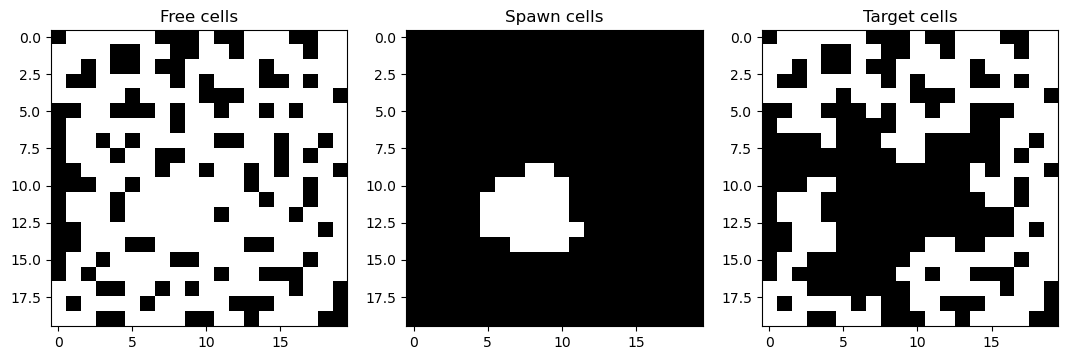

In [4]:
plot_masks()

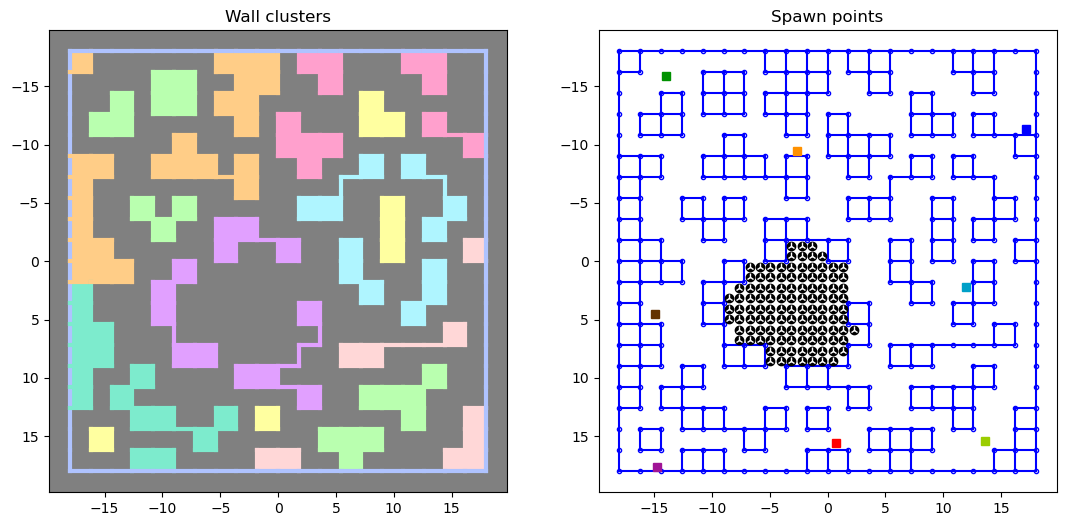

In [5]:
vtor.sampler = MazeSampler(data, n_bots=112, global_spawn_prob=0., rng=0)
plot_maze()

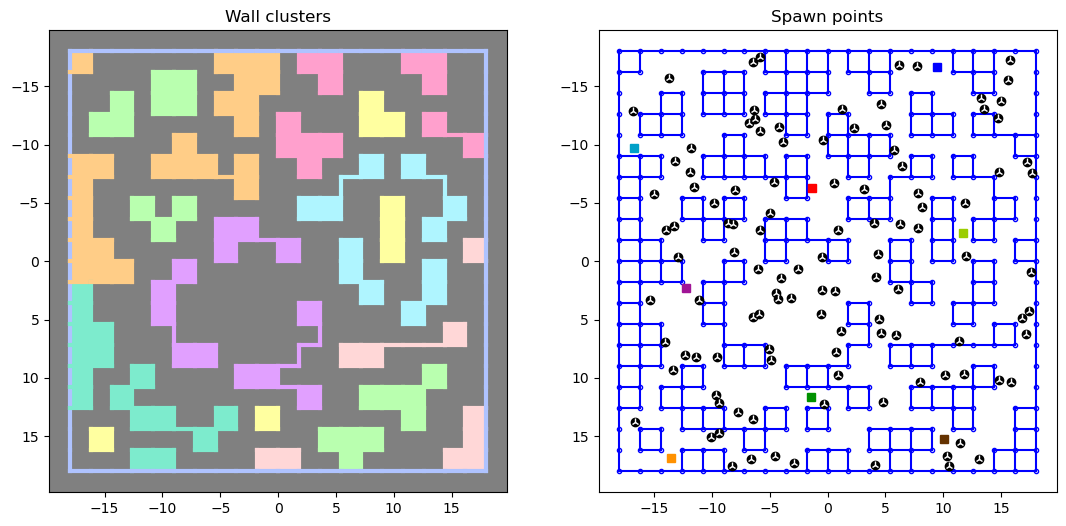

In [6]:
vtor.sampler = MazeSampler(data, n_bots=112, global_spawn_prob=1., rng=1)
plot_maze()

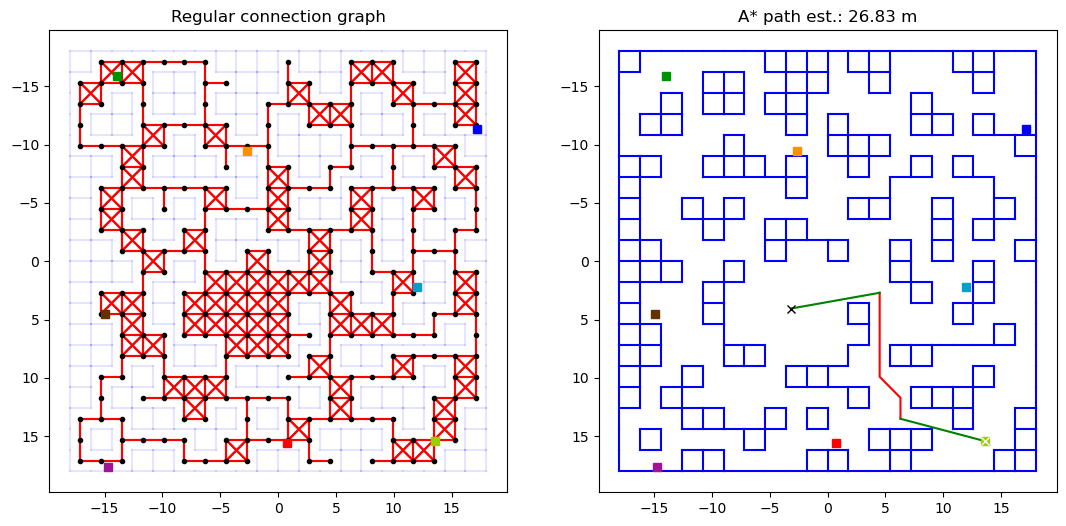

In [7]:
vtor.sampler = MazeSampler(data, n_bots=1, global_spawn_prob=0., rng=0)
plot_path(0)

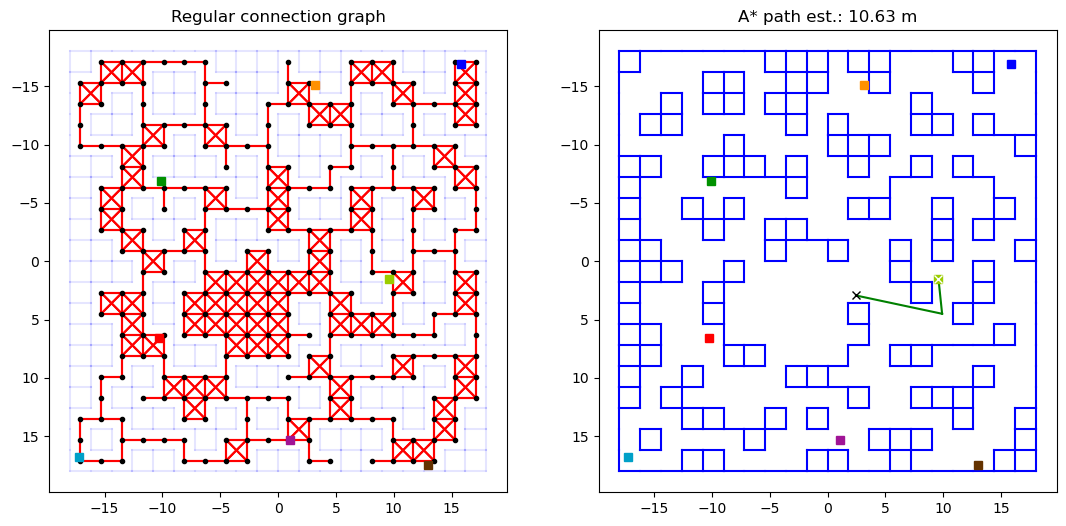

In [8]:
vtor.sampler = MazeSampler(data, n_bots=1, global_spawn_prob=1., rng=37)
plot_path(0)

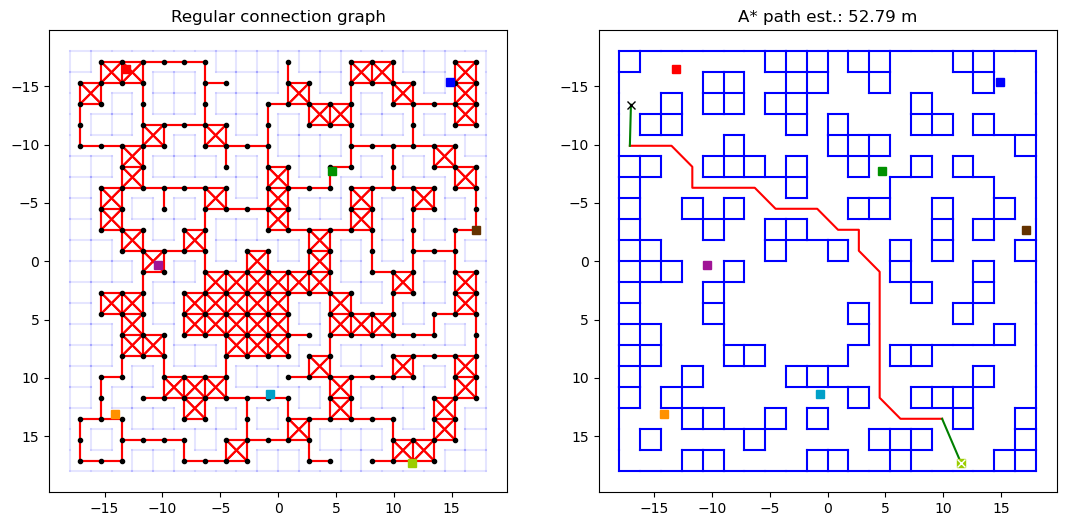

In [9]:
vtor.sampler = MazeSampler(data, n_bots=1, global_spawn_prob=1., rng=42)
plot_path(0)

In [10]:
data.save()